# Lab 4\. Making Choices: Building a Convolutional Model for SVHN

## Overview

In Chapter 3 you trained the `DigitClassifier` on MNIST and watched its accuracy climb. Every component was already chosen for you: the layers, the activation, the loss function, and the optimizer. This lab hands those choices back to you and gives you a harder problem to work with. You will work with the Street View House Numbers (SVHN) dataset, which contains color 32×32 images of digits cropped from photographs of house numbers. The digits are the same ten classes as MNIST, but the images are larger, in color, and cluttered with real-world backgrounds.

You will do two things. First, you will take the MNIST `DigitClassifier` and try it on SVHN, so you can see exactly where and why it fails. Then you will build a small convolutional model that fits the new data, choose its loss function and optimizer at marked decision points, train it, and read its training and test accuracy to judge whether your choices helped. There is no single correct model here. The skill you are practicing is choosing components on purpose and letting the results tell you whether the choice was good.

This is the kind of work you do whenever a model that worked on one dataset meets a new, messier one. Recognizing that the input shape and structure have changed, picking layers that match, and reading the gap between training and test accuracy are everyday tasks when you build models rather than copy them.

## Learning Objectives

By the end of this lab, you should be able to:

- Load the SVHN dataset with Torchvision and inspect the shape of a batch  
- Explain why a model built for MNIST fails on SVHN and modify the architecture to fit the new task  
- Build a convolutional model with `nn.Conv2d` layers sized for color images  
- Select and apply a loss function and an optimizer for a classification task, and justify each choice  
- Train the model and evaluate it by comparing training and test accuracy

## Prerequisites

This course’s labs are **not cumulative**, so this lab does not depend on any prior resources or the state of earlier labs if there are any.

You need the following before you start:

- **A notebook environment:** either a Google account for Google Colab, or a local installation of Jupyter Notebook. Every step in this lab runs on a CPU; no GPU is required.  
- **Python 3.12 or later.** On Colab this is already provided. For a local environment, confirm your version with `python --version`.  
- **PyTorch 2.12.1 and TorchVision 0.17 or later (0.27 preferred),** installed with `pip` in the previous lab. If you are on Colab, these may already be present.  
- The `scipy` package, which Torchvision uses to read SVHN's `.mat` files. It is preinstalled on Colab; on a local machine, install it with `pip install scipy`.  
- **A web browser** (Chrome, Firefox, or Edge are recommended for Colab).

> **Note:** Training a convolutional model on SVHN is noticeably heavier than training the MNIST model was. If you are on Google Colab, switch the runtime to a GPU before you start: open the **Runtime** menu, select **Change runtime type**, and choose a **GPU** hardware accelerator. The lab runs on CPU as well, but each training epoch will take longer.   
>   
>   


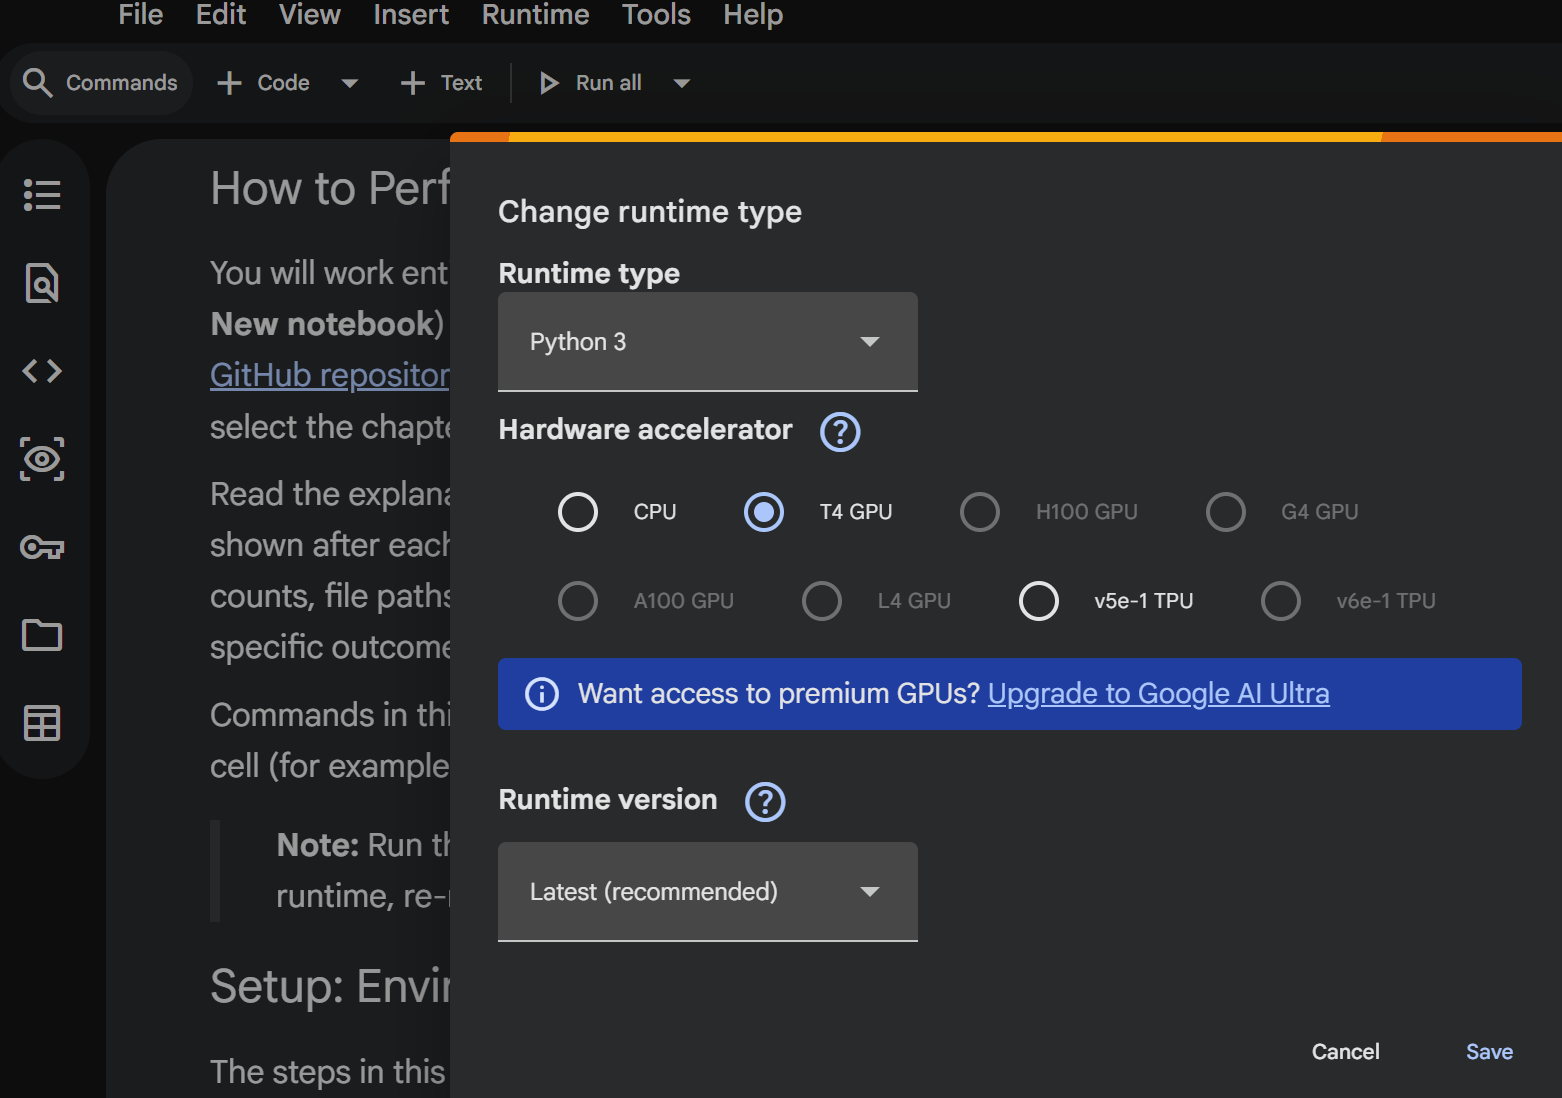

## Estimated Time

Approximately 20–25 minutes of hands-on work, plus training time. On a GPU, training runs in a few minutes; on CPU it can take longer, so plan accordingly.

## How to Perform the Exercise

You will work entirely in one notebook, running cells from top to bottom. Create a new notebook in Google Colab (**File \> New notebook**) or a new `.ipynb` in local Jupyter, and add each code block below as its own cell as you reach it.  Download the chapter 4 lab notebook from the [LFD2002-resources GitHub repository](https://github.com/lftraining/LFD2002-resources.git) from the **LFD2002-resources/labs** directory. In Google Colab, select File, then Upload Notebook, and select the chapter 4 lab notebook you downloaded.

Read the explanation before running each cell, run it, and compare what you see to the Sample Output or Output shown after each block. Sample Output means the exact values will differ from run to run (random tensors, dataset counts, file paths), so match the shape and structure rather than every character. Output marks a checkpoint where a specific outcome confirms the step worked.

Commands in this lab use the notebook form, where a line beginning with `!` runs a shell command from inside a notebook cell (for example, `!pip install ...`). If you run these in a local terminal instead of a notebook cell, drop the leading `!`.

> **Note:** Run the cells in order and only once each, unless a step says otherwise. If you restart the notebook's runtime, re-run the cells from the top, because the variables live in memory and are cleared on restart.

## Setup: Environment Preparation

The steps in this section stand up what the later sections need: the imports, a small transform, the two dataset and dataloader objects, the model from Lab 2, and some functions from Lab 3\. They are not the learning content of the lab, and on a managed course platform some of them may already be done for you. Run them once at the top of your notebook, then move on to Part A.

### Setup 1\. Confirm your libraries and select a device

Confirm the libraries are importable and pick the device the model will run on. Selecting a device once here lets the training and evaluation code use a GPU automatically when one is available, and fall back to CPU when it is not.

In [ ]:
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Sample Output:

```
Using device: cuda
```

If you did not switch on a GPU, this prints `Using device: cpu`, which is expected and fine.

### Setup 2\. Load the SVHN dataset

Download the SVHN training and test splits and wrap each in a `DataLoader`. Torchvision provides SVHN through a dataset class, the same way it provided MNIST, with two differences that matter for your code. SVHN selects its split with a `split` argument set to `"train"` or `"test"`, not with MNIST's `train=True`/`train=False`. And SVHN images are color, so the transform converts each one to a float tensor without changing its three channels.


In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

svhn_train = datasets.SVHN(root="data", split="train", download=True, transform=transform)
svhn_test  = datasets.SVHN(root="data", split="test",  download=True, transform=transform)

svhn_train_loader = DataLoader(svhn_train, batch_size=64, shuffle=True)
svhn_test_loader  = DataLoader(svhn_test,  batch_size=64, shuffle=False)

print(f"Training images: {len(svhn_train)}")
print(f"Test images: {len(svhn_test)}")


Output:

```
Training images: 73257
Test images: 26032
```

The `v2.ToImage()` and `v2.ToDtype(torch.float32, scale=True)` pair converts each image to a float tensor with values scaled to the range 0.0 to 1.0; the older `v2.ToTensor()` is deprecated in current Torchvision, so this lab uses the replacement pair. The batch size of 64 matches the loaders you used for MNIST in Lab 3\. The training loader shuffles so the model does not see the data in the same order every epoch; the test loader does not shuffle, because evaluation order does not matter.

> **Note:** SVHN downloads its files (for example `train_32x32.mat`) directly into the `data/` directory, next to the `MNIST/` folder from earlier labs. Loading these `.mat` files requires the `scipy` package. If you see an error mentioning `scipy` when this cell runs, install it with `pip install scipy` and run the cell again. The raw SVHN files label the digit 0 as `10`, but Torchvision remaps it back to `0` for you, so the labels already run from 0 to 9\.

### Setup 3\. Carry over the model and functions from Lab 3

Re-define the `DigitClassifier` model class and `train` and `evaluate` functions from Lab 3 so this lab runs on its own. They are the same functions you already used, with one addition: each moves its batch of images and labels onto the `device` you selected in Step 1, so the code uses the GPU when one is present. The training loop is the same five-part cycle from Chapter 3 (forward pass, loss, backward pass, `optimizer.step()`, then `optimizer.zero_grad()`), and evaluation uses `model.eval()` and `torch.no_grad()` with `argmax` to count correct predictions.


In [ ]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(784, 128)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

def train(model, loader, optimizer, loss_fn, epochs, device):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # sends to device
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs} - average loss: {running_loss / len(loader):.4f}")

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # sends to device
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total


Running this cell defines the two functions; it produces no output. \[Inferred from docs: the training loop and `model.eval()`/`torch.no_grad()`/`argmax` pattern are documented in the PyTorch 2.13 documentation and were established in Lab 3; the `.to(device)` calls are the only addition.\]

## Part A: Diagnose Why the MNIST Model Does Not Fit SVHN

Before building anything new, see for yourself why the model that worked on MNIST does not work here. Diagnosing the mismatch is what tells you which components have to change.

### Step 1\. Inspect an SVHN batch

Pull one batch from the training loader and print its shape, so you can compare it to the MNIST batches from Lab 3\. Understanding the shape of the input is the first thing that drives every later choice.


In [ ]:
images, labels = next(iter(svhn_train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")


Output:

```
Batch shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
```




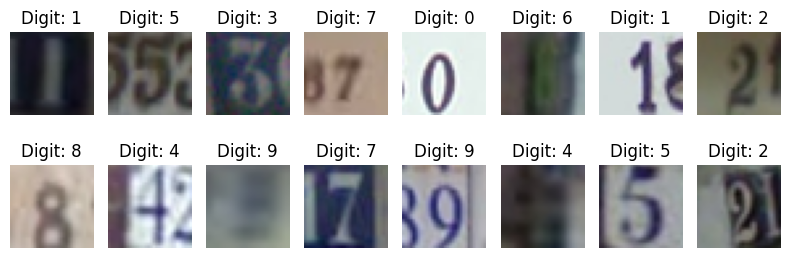


Some example digits from the SVHN dataset.

Read the batch shape as (batch size, channels, height, width). Each SVHN image has 3 channels because it is color, and it is 32 by 32 pixels. An MNIST batch in Lab 3 was `[64, 1, 28, 28]`: one channel because it is grayscale, and 28 by 28 pixels. The two numbers that changed, the channel count and the image size, are exactly the two things the old model was built around.

### Step 2\. Run the DigitClassifier on SVHN and read the error

Try to pass the SVHN batch through the `DigitClassifier` from Lab 2\. This is meant to fail. Seeing the exact error is how you learn to recognize an input-shape mismatch when it happens in your own work.

In [ ]:
digit_model = DigitClassifier()
outputs = digit_model(images)


**Output:** the cell raises a `RuntimeError` about matrix shapes that cannot be multiplied, similar to this:

```
RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x3072 and 784x128)
```

The `DigitClassifier` begins with `nn.Flatten()`, which turns each image into a flat vector. An SVHN image has 3 × 32 × 32 \= 3,072 values, so the batch flattens to `64x3072`. The first Linear layer was built as `nn.Linear(784, 128)`, because a flattened MNIST image has 28 × 28 × 1 \= 784 values. The layer expects 784 inputs and receives 3,072, so the multiplication is impossible and PyTorch stops.

### Step 3\. Decide what the model actually needs

The error points at the input size, and fixing only the number would miss the larger issue.

> **Decision Point:** How should you change the model to handle SVHN? Consider three options: (a) change the first Linear layer's input from 784 to 3,072 and keep the rest as is; (b) rebuild the model around convolutional layers that read the image directly; (c) shrink the SVHN images to 28×28 grayscale so the old model fits.

Option (a) removes the error but keeps a model that flattens the image before doing anything with it, which throws away the two-dimensional arrangement of the pixels. That arrangement matters more for SVHN than it did for clean, centered MNIST digits, because SVHN digits shift around inside the frame and sit against busy backgrounds. Option (c) forces the harder dataset to imitate the easier one and discards the color and detail that make SVHN what it is. Option (b) is the choice this lab follows: a convolutional layer keeps the image's height and width and reuses the same weights across it, so it can find a digit's shape wherever that digit appears. You met `nn.Conv2d`, pooling, and the other layer types in Chapter 2; in Part B you arrange them into a model that reads SVHN images.

> **Note:** Once you finish the lab using option (b), restart the notebook and try a different alternative, either (a) or (c). For option (c), besides the Resize() transform, you will also need a Grayscale(num\_output\_channels=1) transform to make the images MNIST-like.

## Part B: Build and Train a Convolutional Model

Now build a model that fits the data, choose its loss function and optimizer, and train it. Each choice is one you can justify against the task.

### Step 4\. Define the SVHNClassifier

Define a small convolutional model named `SVHNClassifier`. Its first `nn.Conv2d` uses `in_channels=3` to match SVHN's three color channels, which is the change that would have been wrong to skip. Two convolution-and-pooling stages extract features and shrink the image, then `nn.Flatten` and two Linear layers turn those features into ten class scores.


In [ ]:
class SVHNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # -> [batch, 32, 16, 16]
        x = self.pool(self.relu(self.conv2(x)))    # -> [batch, 64, 8, 8]
        x = self.flatten(x)                        # -> [batch, 4096]
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                            # -> [batch, 10] logits
        return x

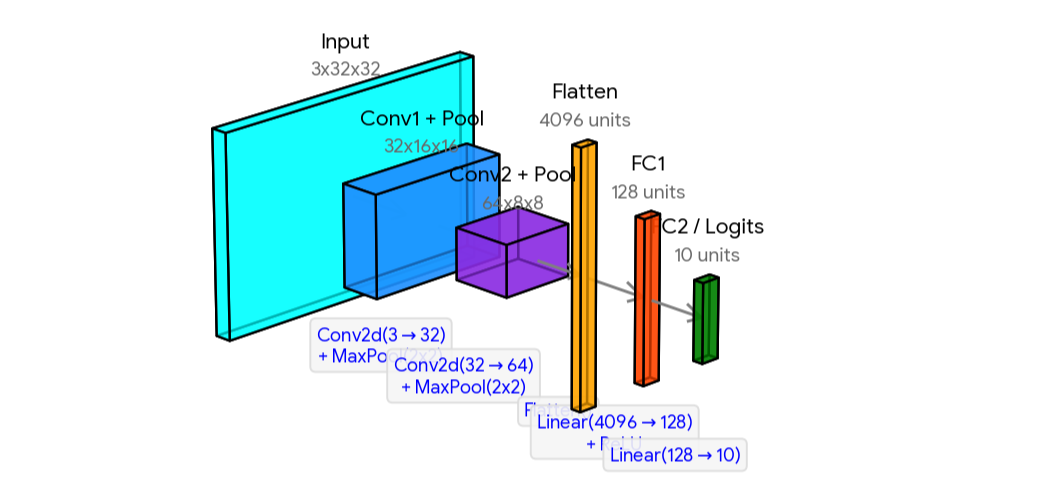


A diagram representation of the SVHNClassifier model



Trace the sizes so the `nn.Linear` input makes sense. Each `nn.Conv2d` uses `kernel_size=3` with `padding=1`, which keeps the height and width the same, so the change in size comes only from pooling. `nn.MaxPool2d(kernel_size=2)` halves the height and width each time it runs: 32 becomes 16 after the first stage, and 16 becomes 8 after the second. The second convolutional layer produces 64 feature maps, so after the second pooling the data is 64 × 8 × 8, which flattens to 64 × 8 × 8 \= 4,096 values. That is why `fc1` is `nn.Linear(64 * 8 * 8, 128)`. The final layer produces ten scores, one per digit, and these are raw logits with no softmax applied.

### Step 5\. Choose a loss function

With the model defined, choose what it should minimize.

> **Decision Point:** SVHN asks the model to pick which digit an image shows, one of ten classes, with integer labels from 0 to 9\. Which loss function from Chapter 3 fits: `nn.CrossEntropyLoss` or `nn.MSELoss`?

This is a classification task, so `nn.CrossEntropyLoss` is the fit. It takes the raw logits from the final layer and the integer class label, and it applies its normalization step internally, which is why the model does not end in a softmax. `nn.MSELoss` is for regression, where the target is a continuous quantity; using it here would tell the model to treat the digit labels as numbers to approximate, which is the wrong goal for classes that are just names. Create the loss function:


In [ ]:
loss_fn = nn.CrossEntropyLoss()


This cell produces no output.

### Step 6\. Choose an optimizer

Now choose how the model updates its parameters from the gradients.

> **Decision Point:** For a first run on a new model, which optimizer would you choose: `torch.optim.SGD` or `torch.optim.Adam`, and what trade-off are you accepting?

Adam is a reasonable first choice, because it adapts each parameter's step size and usually trains well with its default settings, which means less learning-rate tuning before you can tell whether the architecture works at all. The trade-off is that Adam uses more memory than SGD. Instantiate the model, move it to your device, and create an Adam optimizer with a learning rate of 0.001, the same rate you used for the Adam run in Lab 3:


In [ ]:
svhn_model = SVHNClassifier().to(device)  # the model is sent to device
optimizer = torch.optim.Adam(svhn_model.parameters(), lr=0.001)


This cell produces no output. If you wanted a leaner run or tighter control over the training dynamics later, `torch.optim.SGD` with a tuned learning rate would be the alternative to compare against.

### Step 7\. Train the model

Train `svhn_model` for five epochs by calling the `train` function with the loader, optimizer, loss function, and device. Watch the printed loss: it should trend downward from one epoch to the next, which means the optimizer is finding parameters that reduce the error.


In [ ]:
train(svhn_model, svhn_train_loader, optimizer, loss_fn, epochs=5, device=device)


Sample Output:

```
Epoch 1/5 - average loss: 1.1032
Epoch 2/5 - average loss: 0.6417
Epoch 3/5 - average loss: 0.5288
Epoch 4/5 - average loss: 0.4623
Epoch 5/5 - average loss: 0.4157
```

The exact numbers will differ on each run, because the weights start from random values and the training loader shuffles. What matters is the trend: each epoch's average loss should be lower than the one before. If the loss does not fall at all, or swings wildly, that is a signal to check the earlier steps before trusting any accuracy result.

> **Note:** Training for five epochs in Google Colab using a CPU takes around 12 minutes. If a GPU (Testa T4 in free tier) is used instead, it takes less than 2 minutes.

### Step 8\. Evaluate training and test accuracy

Measure accuracy on both splits. Two numbers tell you more than one, because the gap between them shows how well the model generalizes to images it did not learn from.


In [ ]:
train_accuracy = evaluate(svhn_model, svhn_train_loader, device)
test_accuracy = evaluate(svhn_model, svhn_test_loader, device)
print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")


Sample Output:

```
Training accuracy: 91.20%
Test accuracy: 88.75%
```

Optionally, visualize the images and their corresponding predictions using the plot\_predictions() function that takes a model, images, labels, and the device being used to make predictions and plotting them.


In [ ]:
def plot_predictions(model, images, labels, device):
  images, labels = images.to(device), labels.to(device)
  outputs = model(images)
  predictions = outputs.argmax(dim=1)

  n_rows = len(images) // 16 + int((len(images) % 16) > 0)
  fig, axs = plt.subplots(n_rows, 16, figsize=(10, n_rows))
  axs = axs.flatten()
  for i, (label, pred) in enumerate(zip(labels, predictions)):
    axs[i].imshow(images[i].cpu().permute(1, 2, 0))
    axs[i].set_title(f'True: {label.item()}\nPred: {pred.item()}', fontsize=10)
    axs[i].axis('off')
  fig.tight_layout()
  return fig

images, labels = next(iter(svhn_test_loader))
plot_predictions(svhn_model, images, labels, device)

**Sample Output:**

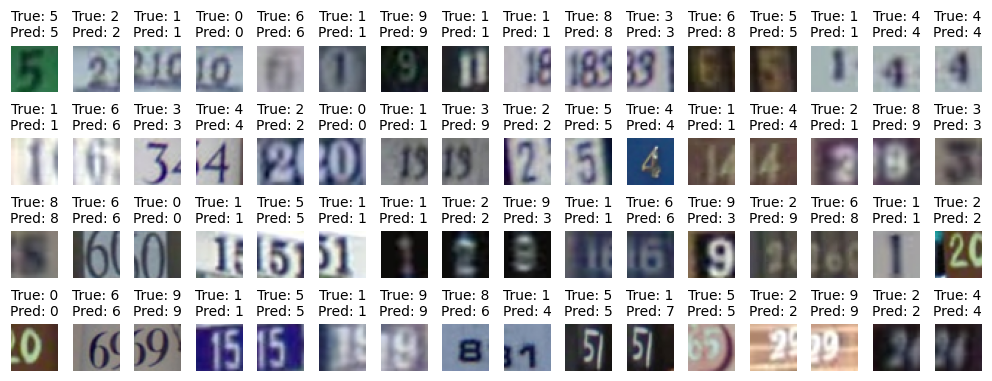

A test accuracy in this range is a large jump over what the flatten-first `DigitClassifier` could have reached on SVHN, and it comes from one deliberate change: reading the image with convolutional layers instead of flattening it first. Compare your two numbers. When training accuracy sits far above test accuracy, the model has started to memorize the training images rather than learn patterns that transfer, which is overfitting.

### Step 12\. Make one deliberate improvement (optional)

If you have time, change one thing and re-measure, so you can see how a single component choice affects the result. Changing one component at a time is what lets you attribute a change in accuracy to a specific decision rather than guessing.

For example, if your training accuracy is much higher than your test accuracy, add a dropout layer, which randomly zeroes some values during training to reduce overfitting. You would add it in `__init__` as `self.dropout = nn.Dropout(0.25)` and apply it in `forward` after the first fully connected layer, for example `x = self.dropout(self.relu(self.fc1(x)))`. Re-instantiate the model, retrain, and compare the new training-to-test gap against the one you saw in Step 11\.

## Cleanup

This lab does not create anything that must be torn down, and part of what it produces may be kept. There are no processes to stop and no services to remove.

**The `data/` directory** holds the downloaded SVHN files. Keeping it means you will not re-download the data if you revisit the notebook. If you need to reclaim disk space, you may delete `data/`SVHN`/`, but the dataset will download again the next time you load it.

On Google Colab the runtime is temporary. When your Colab session ends, the `data/` directory and the loaded objects are cleared. This is expected. In the next chapter you simply re-run the setup cells, which downloads the data again for the new session.

## Summary

You started from a model that mastered MNIST and watched it fail on SVHN the moment the input changed shape, then rebuilt it into a convolutional model that reads color images directly. Along the way you made the two choices the chapter framed as decisions: `nn.CrossEntropyLoss` because the task is classification with integer labels, and `torch.optim.Adam` as a first optimizer whose cost is extra memory. Evaluating training and test accuracy together, rather than trusting one number, is what lets you see whether the model learned patterns that transfer or only memorized its training images. That loop is the habit that carries into any model you build after this course: match the components to the task, train, read the results, and change one thing at a time.



